In [21]:
import pandas
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

main_column = 'Hogwarts House'
with open('../setup.json') as f:
    data = json.load(f)
path = data["interpret_path"]
print(f'path : {path}')
pd.set_option('future.no_silent_downcasting', True)

path : /nfs/homes/lfarina/Desktop/ft_dslr/datasets/dataset_train.csv


In [22]:
def csv_to_dataframe(csv_file: str) -> pandas.DataFrame:
    """Converts a CSV file into a Pandas dataframe"""
    dtf = pandas.read_csv(csv_file)
    return dtf
csv_to_dataframe(path)

,Index,Hogwarts House,First Name,Last Name,Birthday,Best Hand,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
0,0,Ravenclaw,Tamara,Hsu,2000-03-30,Left,58384.0,-487.886086,5.727180,4.878861,4.722,272.035831,532.484226,5.231058,1039.788281,3.790369,0.715939,-232.79405,-26.89
1,1,Slytherin,Erich,Paredes,1999-10-14,Right,67239.0,-552.060507,-5.987446,5.520605,-5.612,-487.340557,367.760303,4.107170,1058.944592,7.248742,0.091674,-252.18425,-113.45
2,2,Ravenclaw,Stephany,Braun,1999-11-03,Left,23702.0,-366.076117,7.725017,3.660761,6.140,664.893521,602.585284,3.555579,1088.088348,8.728531,-0.515327,-227.34265,30.42
3,3,Gryffindor,Vesta,Mcmichael,2000-08-19,Left,32667.0,697.742809,-6.497214,-6.977428,4.026,-537.001128,523.982133,-4.809637,920.391449,0.821911,-0.014040,-256.84675,200.64
4,4,Gryffindor,Gaston,Gibbs,1998-09-27,Left,60158.0,436.775204,-7.820623,NaN,2.236,-444.262537,599.324514,-3.444377,937.434724,4.311066,-0.264070,-256.38730,157.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1595,Gryffindor,Jung,Blank,2001-09-14,Right,49009.0,354.280086,-4.541837,-3.542801,5.702,-497.235066,618.220213,-5.231721,964.219853,3.389086,-0.649983,-250.39401,185.83
1596,1596,Slytherin,Shelli,Lock,1998-03-12,Left,63296.0,367.531174,6.061064,-3.675312,1.757,-643.271092,445.827565,2.238112,1056.147366,5.825263,-0.333962,-246.42719,44.80
1597,1597,Gryffindor,Benjamin,Christensen,1999-10-24,Right,63905.0,544.018925,-3.203269,-5.440189,6.065,-385.150457,635.211486,-5.984257,953.866685,1.709808,0.071569,-251.63679,198.47
1598,1598,Hufflepuff,Charlotte,Dillon,2001-09-21,Left,82713.0,453.676219,3.442831,-4.536762,6.738,-831.741123,383.444937,3.813111,1087.949205,3.904100,-0.531875,-246.19072,-76.81


In [23]:
def scatter_matrix_plot(dtf: pd.DataFrame, house=['Gryffindor'], figsize=(20,20)):
    """Plot a scatter matrix for each course."""
    dtf = dtf.drop(columns='Index', inplace=False)
    nb_features = dtf.select_dtypes(include=['number']).columns.tolist()
    
    # remove the 'Hogwarts House' if it is found in the course list
    if main_column in nb_features:
        nb_features.remove(main_column)

    nb_features.reverse()
    feature_len = len(nb_features)
    house_len = len(house)
    
    font = {'weight': 'light', 'size': 7}
    plt.rc('font', **font)

    # Set up the matrix (subplot)
    figure, axes = plt.subplots(nrows=house_len, ncols=feature_len, squeeze=False, figsize=figsize, sharex=False, sharey=False)

    # Loop on each course (on x and y) to create the matrix
    for x in range(0, house_len):
        for y in range(0, feature_len):
            # Remove the scatter if a course is compared with itself
            if house[x] != nb_features[y]:
                plot_scatter(dtf[[main_column, nb_features[y]]], axes[x, y], house[x], nb_features[y])
            # Add scales only for the first column and the last row
            if x != house_len - 1:
                axes[x, y].tick_params(labelbottom=False)
                axes[x, y].xaxis.set_ticks_position('none')
            else:
                axes[x, y].set_xlabel(nb_features[y].replace(' ', '\n'))
            if y != 0:
                axes[x, y].tick_params(labelleft=False)
                axes[x, y].yaxis.set_ticks_position('none')
            else:
                axes[x, y].set_ylabel(house[x].replace(' ', '\n'))
            axes[x, y].tick_params(labelrotation=45.0)
            axes[x, y].tick_params(labelright=False)
            axes[x, y].tick_params(labeltop=False)
            axes[x, y].spines['right'].set_visible(False)
            axes[x, y].spines['top'].set_visible(False)

    plt.legend(['G', 'H', 'S', 'R'], loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

In [24]:
def plot_scatter(dtf: pd.DataFrame, axe, main_house: str, course: str):
    """Create and plot a scatter to compare two courses (x_name and y_name)"""
    # Extract each house
    _gryffindor = dtf[dtf[main_column] == 'Gryffindor'].copy()
    _hufflepuff = dtf[dtf[main_column] == 'Hufflepuff'].copy()
    _slytherin = dtf[dtf[main_column] == 'Slytherin'].copy()
    _ravenclaw = dtf[dtf[main_column] == 'Ravenclaw'].copy()
    
    _gryffindor[main_column] = _gryffindor[main_column].replace({'Gryffindor': 1} if main_house == 'Gryffindor' else {'Gryffindor': 0}).astype(int)
    _hufflepuff[main_column] = _hufflepuff[main_column].replace({'Hufflepuff': 1} if main_house == 'Hufflepuff' else {'Hufflepuff': 0}).astype(int)
    _slytherin[main_column] = _slytherin[main_column].replace({'Slytherin': 1} if main_house == 'Slytherin' else {'Slytherin': 0}).astype(int)
    _ravenclaw[main_column] = _ravenclaw[main_column].replace({'Ravenclaw': 1} if main_house == 'Ravenclaw' else {'Ravenclaw': 0}).astype(int)
    

    # Plot each house one by one to apply the associate color
    axe.scatter(_gryffindor[course], _gryffindor[main_column], s=2, color='red', alpha=0.5)
    axe.scatter(_hufflepuff[course], _hufflepuff[main_column], s=2, color='yellow', alpha=0.5)
    axe.scatter(_slytherin[course], _slytherin[main_column], s=2, color='green', alpha=0.5)
    axe.scatter(_ravenclaw[course], _ravenclaw[main_column], s=2, color='blue', alpha=0.5)
    axe.set_yticks([0, 0.5, 1])
    axe.set_xticks([dtf[course].min(), (dtf[course].min() + dtf[course].max()) // 2, dtf[course].max()])

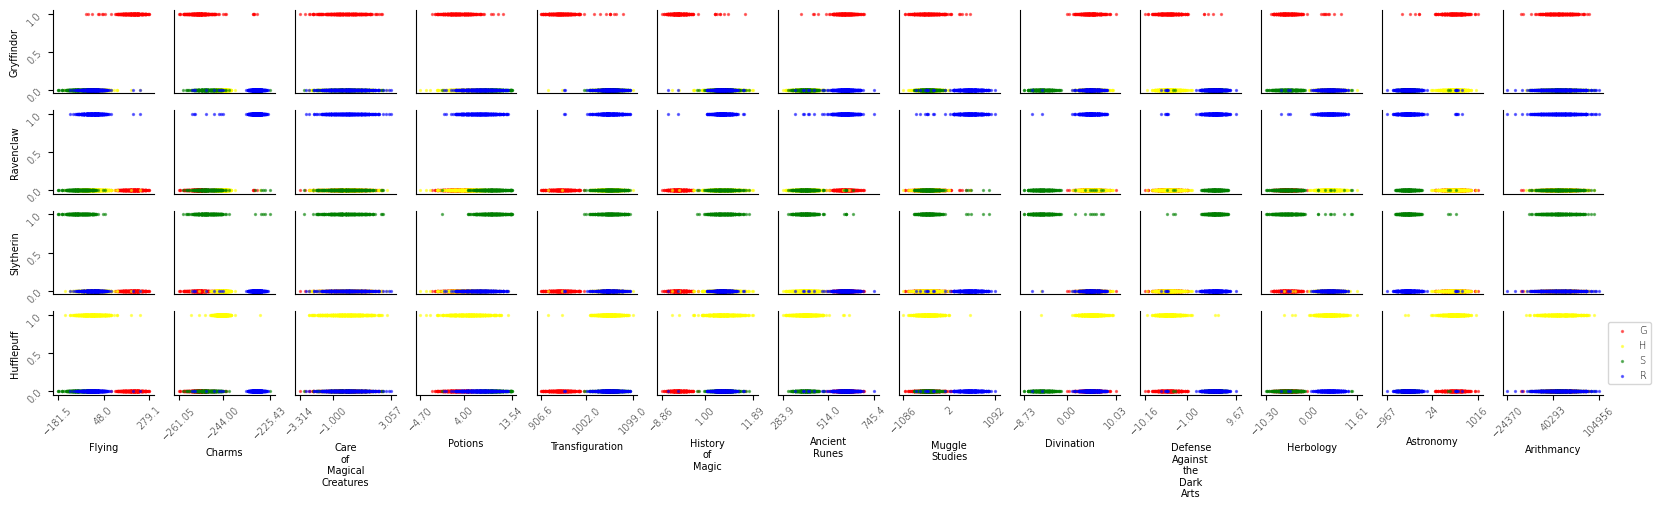

In [25]:
dtf = csv_to_dataframe(path)
scatter_matrix_plot(dtf, house=['Gryffindor', 'Ravenclaw', 'Slytherin', 'Hufflepuff'], figsize=(20,5))